# Question & Background Information

This dataset comes from Kaggle and is compiled as part of the Abracadabra project. It contains approximately 550,000 Spotify tracks with lyrics, emotion labels, and audio features per song including tempo, energy, danceability, acousticness, and more. The dataset has 39 columns and utilizes a wide range of songs.

**Our central question is: how well audio features predict if a song is good for studying/doing work?** This is important because platforms like Spotify heavily rely on audio characteristics, such as tempo, key, loudness, and danceability, to suggest and curate playlist recommendations for users based on their mood and listening habits.

If audio features can reliably predict whether a song will improve a student's productivity and work performance, Spotify would greatly benefit from the success. This success would lead to ultimately more subscriptions and listening hours. Studies have shown that when a student listens to 'good study music' their productivity will increase compared to distracting and even no music at all. For example, slower tempo, and low danceability can put a student in the locked in zone. When in contrast fast moving songs that are 'Good for Party' would lead a student to distraction and poor work production. By identifying these patterns, recommendation algorithms can generate playlists for users such as 'study mode', 'in the library', or 'academic weapon!' with greater precision.

At the same time, personal experience does play an important role in music and how individuals utilize songs in different settings. This may not be captured in the data. This means that while audio features may provide useful signals about songs, they likely offer an incomplete picture of how much productivity a song can foster.

We will explore this question of if audio features can predict if a song is good for studying or not and what features lead to this decision to find if we can create a model to accurately predict this binary classification. We want to see if data alone, not accounting for personal experience, can classify songs correctly.

We will approach this with two models:
1. **Logistic Regression**: supervised exploration of whether songs can be classified right or left of the good for study threshold using features such as tempo, instrumentalness, and other numeric values
2. **Decision Tree**: a formal classification model to predict if a song is good for studying and will promote productivity

# Imports and Load Data 

In [1]:
#load libraries
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import graphviz
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, precision_score, ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier

/workspaces/ML_Final_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the dataset from Kaggle
path = kagglehub.dataset_download("devdope/900k-spotify")

# Load the specific CSV from that path
# The file in this dataset is named 'spotify_dataset.csv'
df = pd.read_csv(f"{path}/spotify_dataset.csv")

print(df.head())

  Artist(s)                       song  \
0       !!!  Even When the Waters Cold   
1       !!!         One Girl / One Boy   
2       !!!          Pardon My Freedom   
3       !!!                        Ooo   
4       !!!                 Freedom 15   

                                                text Length  emotion    Genre  \
0  Friends told her she was better off at the bot...  03:47  sadness  hip hop   
1  Well I heard it, playing soft From a drunken b...  04:03  sadness  hip hop   
2  Oh my god, did I just say that out loud? Shoul...  05:51      joy  hip hop   
3  [Verse 1] Remember when I called you on the te...  03:44      joy  hip hop   
4  [Verse 1] Calling me like I got something to s...  06:00      joy  hip hop   

           Album       Release Date     Key  Tempo  ...  \
0       Thr!!!er    29th April 2013   D min    105  ...   
1       Thr!!!er    29th April 2013  A# min    117  ...   
2  Louden Up Now      8th June 2004   A Maj    121  ...   
3          As If  16th O

# EDA

In [3]:
# explore the dataset's columns, non-null count, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  551435 non-null  str    
 12  Explicit                   

In [4]:
# get a summary statistics of the dataset
df.describe()

,Tempo,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,...,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,7.152255,0.061809,...,0.030772,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938
std,29.185533,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,20.589200,0.240808,...,0.172700,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512
min,31.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647
25%,97.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926
50%,120.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078
75%,140.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079
max,200.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,100.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# see the total na values in each column
df.isna().sum()

Artist(s)                          0
song                              16
text                               0
Length                             0
emotion                            0
Genre                              0
Album                             52
Release Date                       0
Key                                0
Tempo                              0
Loudness (db)                      0
Time signature                     8
Explicit                           0
Popularity                         0
Energy                             0
Danceability                       0
Positiveness                       0
Speechiness                        0
Liveness                           0
Acousticness                       0
Instrumentalness                   0
Good for Party                     0
Good for Work/Study                0
Good for Relaxation/Meditation     0
Good for Exercise                  0
Good for Running                   0
Good for Yoga/Stretching           0
G

In [ ]:
# print column names for easy reference
print(df.columns)

Index(['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album',
       'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness',
       'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness',
       'Good for Party', 'Good for Work/Study',
       'Good for Relaxation/Meditation', 'Good for Exercise',
       'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving',
       'Good for Social Gatherings', 'Good for Morning Routine',
       'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1',
       'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2',
       'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3'],
      dtype='str')


In [7]:
# drop columns not needed for analysis
# some columns have many missing values and others are just not relevent or bring too much noice so will be dropped
df = df.drop(columns=['song', 'text', 'Length', 'Genre', 'Album', 'Release Date', 'Artist(s)', 'Popularity', 'Liveness', 'Similar Artist 1', 'Similar Artist 2', 'Similar Artist 3', 'Similar Song 1', 'Similar Song 2', 'Similar Song 3', 'Similarity Score 1', 'Similarity Score 2', 'Similarity Score 3'])
# drop all the 'Good for ___' columns due to data leakage concerns except the target variable 'Good for Work/Study' becuase will drop later after creating target variable
df = df.drop(columns=['Good for Party', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'])
# confirm the columns have been dropped
df.columns

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Energy', 'Danceability', 'Positiveness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Good for Work/Study'],
      dtype='str')

In [8]:
# Drop rows with missing values in the remaining columns
df = df.dropna()
#confirm the missing values have been dropped
df.isna().sum()

emotion                0
Key                    0
Tempo                  0
Loudness (db)          0
Time signature         0
Explicit               0
Energy                 0
Danceability           0
Positiveness           0
Speechiness            0
Acousticness           0
Instrumentalness       0
Good for Work/Study    0
dtype: int64

For the categorical columns, do additional cleaning on them:

In [30]:
# view value counts of emotion column and print the number of unique values
print(df['emotion'].nunique())
print(df['emotion'].value_counts())

13
emotion
joy          209006
sadness      171073
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64


In [32]:
# Clean up the emotion column more to ensure consistency and collapse rare emotions into other
df['emotion'] = df['emotion'].replace('Love','love')
df['emotion'] = df['emotion'].replace('angry','anger')
df['emotion'] = df['emotion'].replace(['surprise', 'True', 'pink', 'thirst', 'confusion', 'interest'],'other')
# view value counts of emotion column and print the number of unique values after cleaning
print(df['emotion'].nunique())
print(df['emotion'].value_counts())

6
emotion
joy        209006
sadness    171073
anger      109679
fear        28097
love        27966
other        5614
Name: count, dtype: int64


In [33]:
# view value counts of key column and print the number of unique values
print(df['Key'].nunique())
print(df['Key'].value_counts())

24
Key
C Maj     47744
G Maj     47464
D Maj     44568
C# Maj    44409
A Maj     33849
G# Maj    26045
B min     25772
E min     22348
F Maj     22298
A min     21093
A# min    20260
B Maj     19762
E Maj     19633
F# min    19529
F# Maj    19468
F min     19073
C# min    18583
A# Maj    16250
G min     14558
C min     12224
D min     10455
G# min    10293
D# Maj     9233
D# min     6524
Name: count, dtype: int64


In [ ]:
# collapse into 2 categories: Major or Minor
# after doing some research it was found that the major/minor is more meaningful than individual key names for impacting the mood of a listener

# first make it all lower case to ensure consistency
# then use .apply to create a funciton so if it contains 'maj' it will be categorized as 'major', and if not it will be 'minor'
df['Key'] = df['Key'].str.lower().apply(lambda x: 'major' if 'maj' in x else 'minor')
# view value counts of key column and print the number of unique values after collapsing
print(df['Key'].nunique())
print(df['Key'].value_counts())

2
Key
major    350723
minor    200712
Name: count, dtype: int64


In [35]:
# view value counts of Loudness (db) column and print the number of unique values adn the column type
print(df['Loudness (db)'].nunique())
print(df['Loudness (db)'].value_counts())
print(df['Loudness (db)'].dtype)

3746
Loudness (db)
-6db        10611
-7db         8986
-5db         8221
-8db         7010
-4db         6528
            ...  
3.64db          1
-47.06db        1
-36.07db        1
-28.62db        1
-43.72db        1
Name: count, Length: 3746, dtype: int64
str


In [36]:
# strip the 'db' from the Loudness (db) column and convert to numeric
df['Loudness (db)'] = df['Loudness (db)'].str.replace('db', '').astype(float)

In [37]:
# verify dtype and that the values have been converted to numeric correctly
print(df['Loudness (db)'].dtype)
print(df['Loudness (db)'].sort_values(ascending=False).head(5))
print(df['Loudness (db)'].sort_values(ascending=True).head(5))

float64
1276      4.98
511697    4.11
527718    3.78
486936    3.74
486911    3.74
Name: Loudness (db), dtype: float64
416315   -50.06
416316   -50.06
416318   -50.06
416314   -50.06
335646   -48.76
Name: Loudness (db), dtype: float64


In [38]:
# view value counts of Explicit column and print the number of unique values
print(df['Explicit'].nunique())
print(df['Explicit'].value_counts())

2
Explicit
No     389374
Yes    162061
Name: count, dtype: int64


Understand the class balance of the target with the prevalence

In [39]:
# get the number of unique values in the target variable and the count of each value
print(df['Good for Work/Study'].nunique())
print(df['Good for Work/Study'].value_counts())

2
Good for Work/Study
0    510118
1     41317
Name: count, dtype: int64


In [40]:
# calculate the prevalence of the target variable
prevalence = (41317/(510118+41317))
print(f"Prevalence of Good for Work/Study: {prevalence:.4f}")

Prevalence of Good for Work/Study: 0.0749


This is concerning as it is very unbalanced.

Thought Process: Need to straftify the test/train and run class_weight = balanced on models

### Graphs with an Emphasis on Variables we Believe to be Important For Analysis

In [ ]:
# print the datatypes of df
print(df.dtypes)

emotion                    str
Key                        str
Tempo                    int64
Loudness (db)          float64
Time signature             str
Explicit                   str
Energy                   int64
Danceability             int64
Positiveness             int64
Speechiness              int64
Acousticness             int64
Instrumentalness         int64
Good for Work/Study      int64
dtype: object


<Axes: >

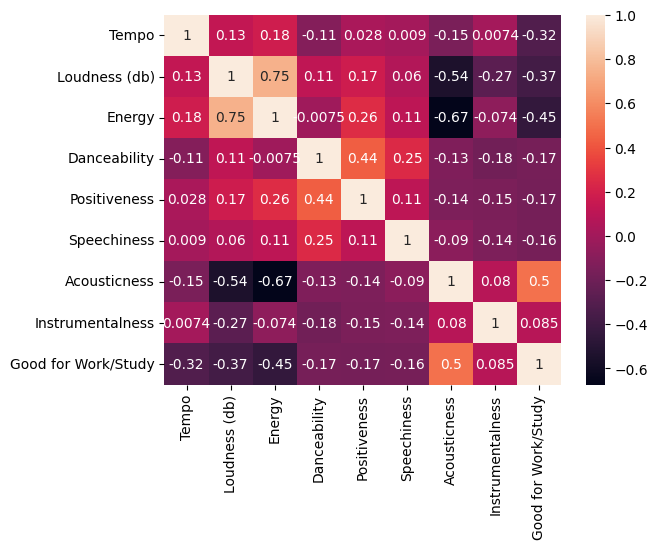

In [43]:
# print a correlation matrix only using the numeric data types in df
numeric_features = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix, annot=True)

Seems like energy and loudness have high correlation but not too high to be worried about multicollinearity.

Good for study also looks to corrlate with acostoicness. This tells us that that may be a good factor to predicit off of.

In [45]:
# create x and y dataset for modeling
#target variable
y = df['Good for Work/Study']

# drop target variable from X dataset along 
X = df.drop(columns=['Good for Work/Study'])

In [46]:
# make sure Good for Work/Study is dropped from X dataset
print(X.columns)
# print the shape of X and y to confirm they are the same length
print(X.shape)
print(y.shape)

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Energy', 'Danceability', 'Positiveness', 'Speechiness',
       'Acousticness', 'Instrumentalness'],
      dtype='str')
(551435, 12)
(551435,)


In [47]:
# create categorical features 
categorical_features = X.select_dtypes(include=['str'])
# create numeric features 
numeric_features = X.select_dtypes(include=['int64', 'float64'])

In [49]:
# print the datatypes of X once more
print(X.dtypes)

emotion                 str
Key                     str
Tempo                 int64
Loudness (db)       float64
Time signature          str
Explicit                str
Energy                int64
Danceability          int64
Positiveness          int64
Speechiness           int64
Acousticness          int64
Instrumentalness      int64
dtype: object


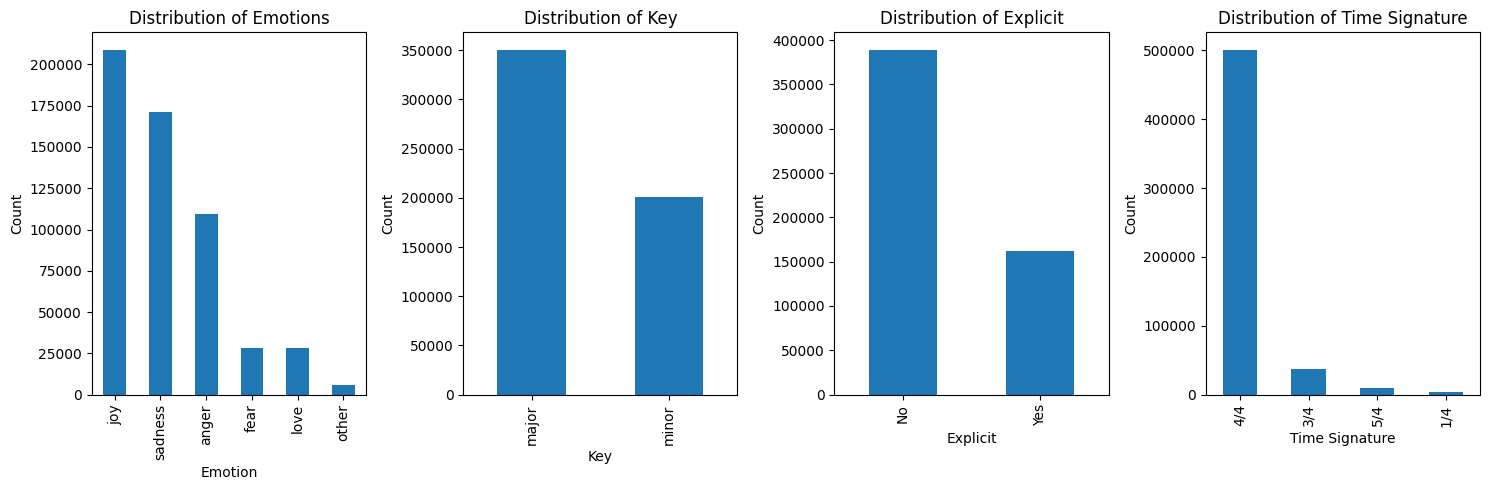

In [50]:
# see the distribution of the categorical features, start with emotion then do Key and Explicit and Time Signiture

plt.figure(figsize=(15,5))

# Emotion
plt.subplot(1,4,1)
categorical_features['emotion'].value_counts().plot(kind='bar')
plt.title("Distribution of Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")

# Key
plt.subplot(1,4,2)
categorical_features['Key'].value_counts().plot(kind='bar')
plt.title("Distribution of Key")
plt.xlabel("Key")
plt.ylabel("Count")

# Explicit
plt.subplot(1,4,3)
categorical_features['Explicit'].value_counts().plot(kind='bar')
plt.title("Distribution of Explicit")
plt.xlabel("Explicit")
plt.ylabel("Count")

#Time signature
plt.subplot(1,4,4)
categorical_features['Time signature'].value_counts().plot(kind='bar')
plt.title("Distribution of Time Signature")
plt.xlabel("Time Signature")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

- joy and sadness really take over the emotion cat
- major and minor are somewhat balenced
- most of the songs are not explicit
- 4/4 time signiture is really dominating

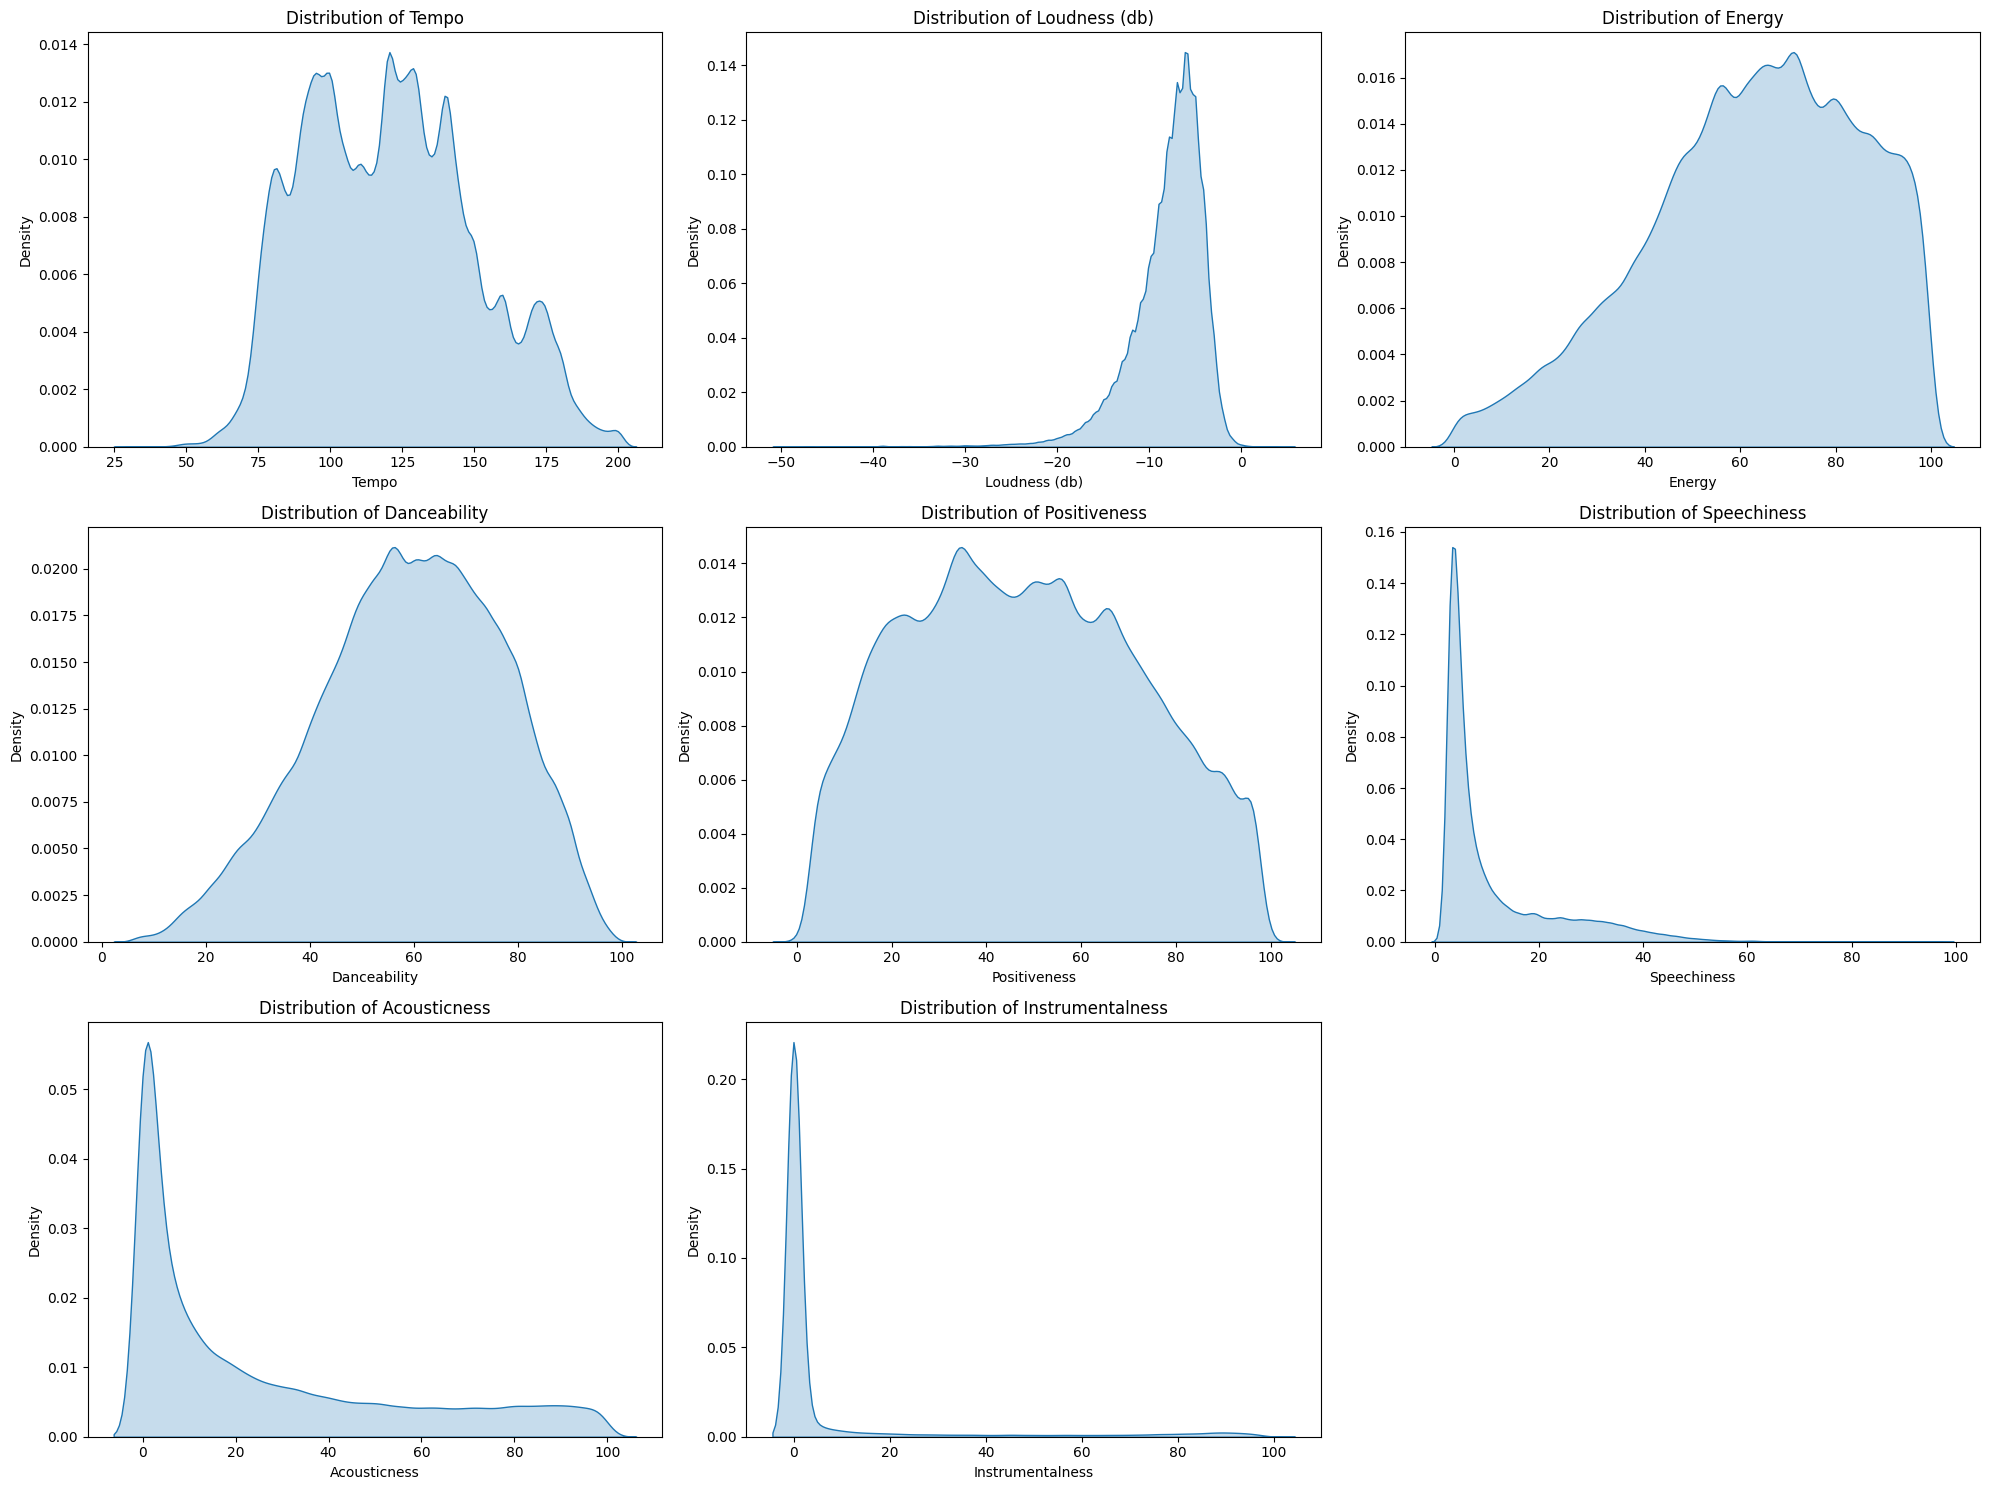

In [51]:
# see kde plots of the numeric features to see their distribution and if there are any outliers
# make a loop though beucase its too long to do this manually

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(numeric_features[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

Speechiness, acousticness, and instrumentalness are heavily right-skewed, so we apply a log transformation to reduce extreme values and make the data more stable for logistic regression.

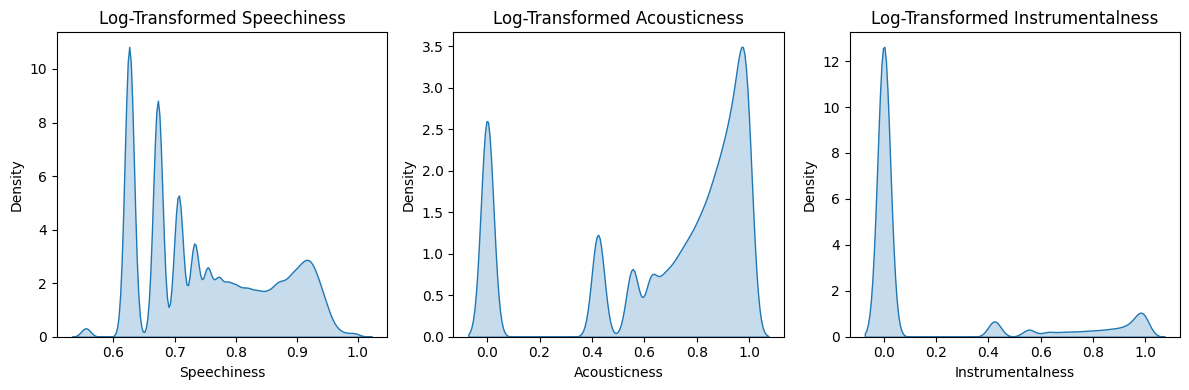

In [54]:
cols = ['Speechiness', 'Acousticness', 'Instrumentalness']

for col in cols:
    X[col] = np.log1p(X[col])

plt.figure(figsize=(12,4))

#plot them again to see the difference after log transformation
for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(X[col], fill=True)
    plt.title(f"Log-Transformed {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

The log transformation reduced skew and made the data more balanced, but many values are still near zero because many songs naturally have low levels of these features. This could still help the model make better predictions though

# Methods 

## Model 1 - Logistic Regression - solver='lbfgs'

In [57]:
# make x and y
# make categorical_features and numerical_features into a list of column names not DataFrames
categorical_features = categorical_features.columns.tolist()
numeric_features = numeric_features.columns.tolist()
x = X[categorical_features + numeric_features]
y = df['Good for Work/Study']

In [58]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [59]:
X_raw = ColumnTransformer(
    transformers=[
        ('categorical_features', OneHotEncoder(handle_unknown='ignore'), categorical_features), 
        ('numeric_features', MinMaxScaler(), numeric_features)
    ])

# create pipeline with column transformer and logistic regression model
pipeline1 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])


# fit the data into pipeline
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

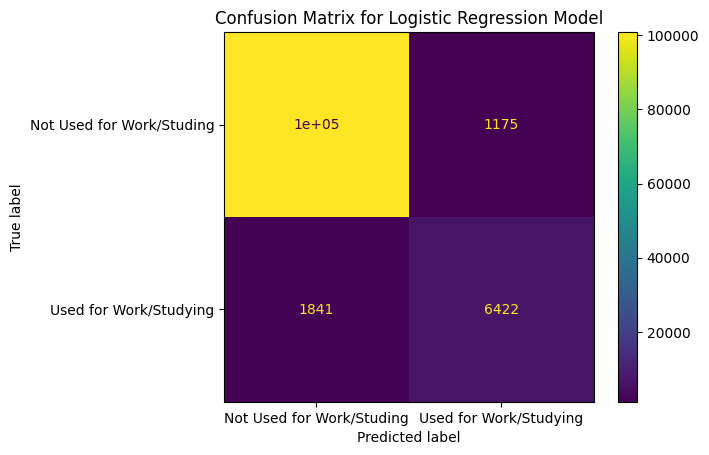

                           precision    recall  f1-score   support

Not Used for Work/Studing       0.98      0.99      0.99    102024
   Used for Work/Studying       0.85      0.78      0.81      8263

                 accuracy                           0.97    110287
                macro avg       0.91      0.88      0.90    110287
             weighted avg       0.97      0.97      0.97    110287



In [60]:
# use the pipeline to predict on the test set and then create a confusion matrix and classification report to evaluate the model performance
# predict 
y_pred_1 = pipeline1.predict(X_test)
# create confusion matrix and classification report
confusion_matrix1 = confusion_matrix(y_test, y_pred_1)
# create the display of the confusion matrix 
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix1, display_labels=['Not Used for Work/Studing', 'Used for Work/Studying'])
# plot it 
disp1.plot()
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
#print classification report with correct target names
print(classification_report(y_test, y_pred_1, target_names=['Not Used for Work/Studing', 'Used for Work/Studying']))

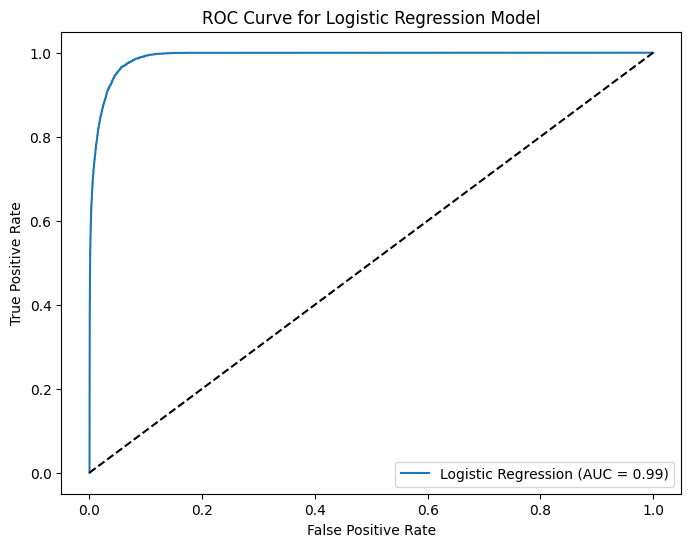

Model 1 ROC-AUC: 0.9905


In [61]:
# create a ROC curve and calculate the AUC score for the model using the pipeline to predict probabilities on the test set
fpr1, tpr1, threshold1 = roc_curve(y_test, pipeline1.predict_proba(X_test)[:, 1])
auc1 = roc_auc_score(y_test, pipeline1.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
# plot it 
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {auc1:.2f})')
# plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--') 
# add labels and a title and legend 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.show()
# print the AUC score for the model
print(f"Model 1 ROC-AUC: {auc1:.4f}")

## Model 2 - Logistic Regression - solver='saga' - class_weight='balanced'

In [62]:
# create pipeline with column transformer and logistic regression model
# use solver = 'saga' and class_weight='balanced'
pipeline2 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=42))
])


# fit the data into pipeline
pipeline2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

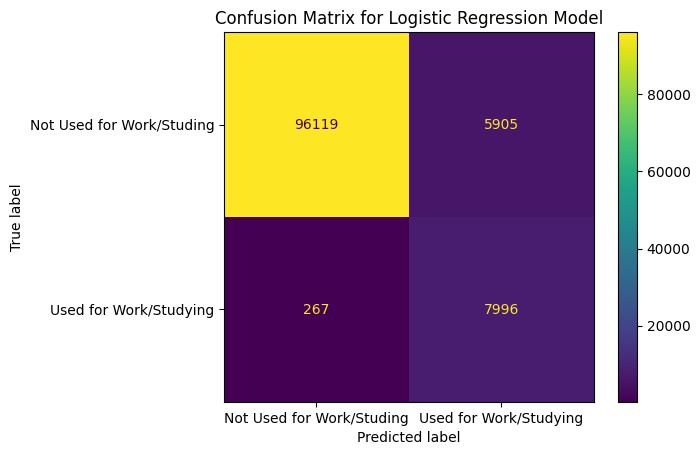

                           precision    recall  f1-score   support

Not Used for Work/Studing       1.00      0.94      0.97    102024
   Used for Work/Studying       0.58      0.97      0.72      8263

                 accuracy                           0.94    110287
                macro avg       0.79      0.95      0.85    110287
             weighted avg       0.97      0.94      0.95    110287



In [63]:
# use the pipeline to predict on the test set and then create a confusion matrix and classification report to evaluate the model performance
# predict 
y_pred_2 = pipeline2.predict(X_test)
# create confusion matrix and classification report
confusion_matrix2 = confusion_matrix(y_test, y_pred_2)
# create the display of the confusion matrix 
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix2, display_labels=['Not Used for Work/Studing', 'Used for Work/Studying'])
# plot it 
disp1.plot()
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
#print classification report with correct target names
print(classification_report(y_test, y_pred_2, target_names=['Not Used for Work/Studing', 'Used for Work/Studying']))

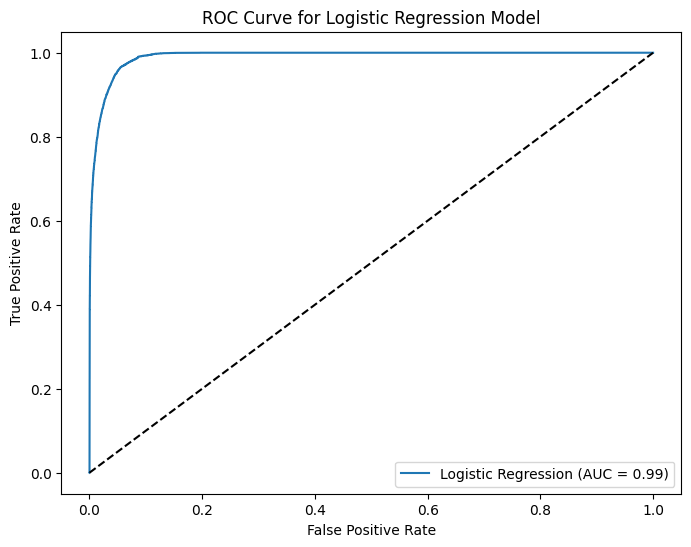

Model 2 ROC-AUC: 0.9906


In [64]:
# create a ROC curve and calculate the AUC score for the model using the pipeline to predict probabilities on the test set
fpr2, tpr2, threshold2 = roc_curve(y_test, pipeline2.predict_proba(X_test)[:, 1])
auc2 = roc_auc_score(y_test, pipeline2.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
# plot it 
plt.plot(fpr2, tpr2, label=f'Logistic Regression (AUC = {auc2:.2f})')
# plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--') 
# add labels and a title and legend 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.show()
# print the AUC score for the model
print(f"Model 2 ROC-AUC: {auc2:.4f}")

Changing the solver to saga and adding in class_weights=balanced did not change the ROC-AUC score. However, precision increased on 'Not Used for Work/Studying' from 0.98 to 1.0, but precision decreased for 'Used for Work/Studying' by 0.85 to 0.57.

## Model 3 - Decision Tree

In [65]:
# Build the pipeline – a single-step pipeline wrapping the classifier
pipe = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=1000))
])

## Model 4 - Random Forest

In [66]:
#resplit 
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [67]:
# editthe pipeline1 for Random Forest Classifier

pipeline1 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', RandomForestClassifier(random_state=42))
])

# fit the data into pipeline
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [68]:
# new predictions  
forest_prediction = pipeline1.predict(X_test)
forest_probability = pipeline1.predict_proba(X_test)

In [69]:
# new results dataframe 
forest_results = pd.DataFrame({
    'target': y_test,
    'pred': forest_prediction,
    'prob_not_good_for_study': forest_probability[:, 0], # first column
    'prob_good_for_study': forest_probability[:, 1] # second column
})

In [70]:
# view results
forest_results.head()

,target,pred,prob_not_good_for_study,prob_good_for_study
131919,0,0,1.00,0.00
149163,0,0,1.00,0.00
548637,0,0,1.00,0.00
150040,0,0,1.00,0.00
464540,1,1,0.01,0.99


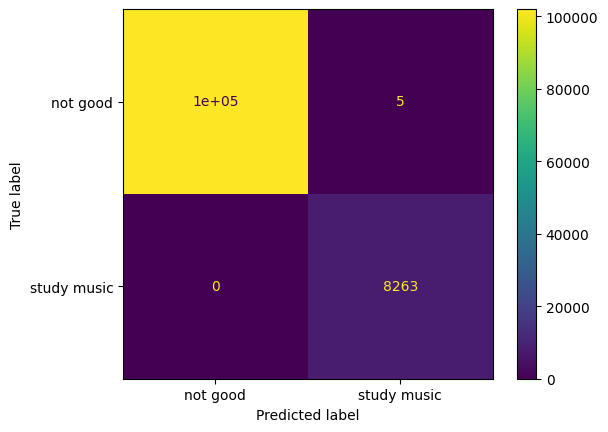

In [71]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, forest_prediction, display_labels=['not good', 'study music'])

In [72]:
print(metrics.classification_report(y_test, forest_prediction, target_names=['not good', 'study music'])) 

              precision    recall  f1-score   support

    not good       1.00      1.00      1.00    102024
 study music       1.00      1.00      1.00      8263

    accuracy                           1.00    110287
   macro avg       1.00      1.00      1.00    110287
weighted avg       1.00      1.00      1.00    110287



# Model Evaluation

oejfweuf

# Conclusion

sufsd

# Team Contribution

All team members - Natalie Schweickert, Mackenzie Kleczynski, and Audrey Stelle - contributed equally to this project.